# <center>Metody Numeryczne</center>

# Laboratorium 10: Aproksymacja


**Wykonał:** Aleksander Młynarski

<br>

### **Metoda zaliczenia:**

Podczas zajęć należy wykonać poniższe polecenia oraz udzielić odpowiedzi na pytania zamieszczone w treści zadań. 

Wszystkie funkcje wymagane w ramach ćwiczenia należy zaimplementować w pliku `main.py`. Poprawność ich działania należy zweryfikować za pomocą testów jednostkowych dostępnych w pliku `test_main.py`.

### **Cel zajęć:**


Aproksymacja funkcji jest fundamentalnym zagadnieniem w analizie numerycznej, które polega na przybliżaniu funkcji bardziej skomplikowanej przez funkcję prostszą. Jest to szczególnie użyteczne w przypadkach, kiedy mamy do czynienia z funkcjami trudnymi do analizy lub gdy potrzebujemy szybkich obliczeń numerycznych.

**[Metoda Najmniejszych Kwadratów](https://en.wikipedia.org/wiki/Least-squares_function_approximation)**

Metoda najmniejszych kwadratów jest jedną z najczęściej stosowanych technik aproksymacji. Polega ona na minimalizacji sumy kwadratów różnic między wartościami obserwowanymi, a wartościami przewidywanymi przez model aproksymacyjny. Matematycznie, dla zbioru danych $(x_i, y_i)$ poszukiwana jest funkcja $f(x)$, która minimalizuje:
$$
S = \sum_{i=1}^n \left(y_i - f(x_i)\right)^2
$$

**[Funkcje Sklejane (Splines)](https://en.wikipedia.org/wiki/Spline_(mathematics))**

Funkcje sklejane, znane również jako splines, to kolejna popularna technika aproksymacji. Splines to ciągłe i gładkie funkcje, które są definiowane kawałkami przez wielomiany. W przeciwieństwie do globalnych metod aproksymacji, jak wielomiany wysokiego stopnia, splines unikają problemu oscylacji, oferując lepszą kontrolę nad kształtem krzywej aproksymacyjnej.

**[B-Splines](https://en.wikipedia.org/wiki/B-spline)**

B-Splines (krzywe B-sklejane) stanowią rozszerzenie idei funkcji sklejanych. Są to specjalne rodzaje splines, które zapewniają dodatkową elastyczność i kontrolę nad kształtem krzywej. B-splines są zdefiniowane jako liniowa kombinacja funkcji bazowych.



### **Uwagi wstępne:**
- Funkcje wymagające implementacji (lub zaimplementowane na poprzednich laboratoriach) oznaczone są pochyłą czcionką maszynową (np. *`my_func()`*).

- W skrypcie stosuje się następujące skróty:

    - `np` - `numpy`,
    - `sp` - `scipy`.

---

In [1]:
# !python -m pip install numpy scipy matplotlib

import main

import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

---

### **Zadanie 1.**

W ramach zadania należy wykonać aproksymację liniową funkcji $\sin(x)$ na przedziale $[0, 2\pi]$ używając metody najmniejszych kwadratów. 

**Punkt 1.**
1. Zaimplementuj funkcję *`linear_least_squares()`* wykonującą aproksymację liniową metodą najmniejszych kwadratów.

**Punkt 2.**
1. Wygeneruj wektor $\mathbf{x}$ składający się z minimum $50$ równoodległych punktów z przedziału $[0, 2\pi]$.

2. Wyznacz wektor $\mathbf{y}$ taki, że $y_i = \sin(x_i)$, gdzie $x_i$ i $y_i$ to $i$-te elementy odpowiednio wektora $\mathbf{x}$ i $\mathbf{y}$.

3. Wyznacz aproksymację liniową funkcji $y = \sin(x)$ kożystając z metody zaimplementowanej w **Punkcie 1.**

4. Wyrysuj na wykresie wykres funkcji oraz wyznaczoną linię aproksymacji.

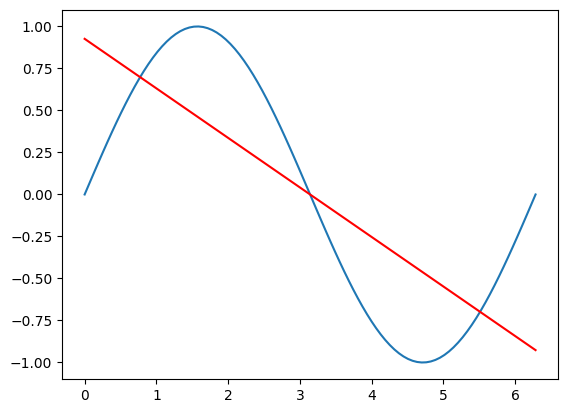

In [2]:
# ===== Twoja implementacja tutaj =====

def linear_least_squares(x: np.ndarray, y: np.ndarray) -> np.ndarray | None:
    try:
        if x.ndim != 1 or y.ndim != 1 or x.shape[0] != y.shape[0]:
            return None
        n = x.shape[0]
        x_mean = np.mean(x)
        y_mean = np.mean(y)

        Sxy = np.sum((x - x_mean) * (y - y_mean))
        Sxx = np.sum((x - x_mean) ** 2)

        if Sxx == 0:
            return None

        a = Sxy / Sxx
        b = y_mean - a * x_mean

        return np.array([a, b])
    except(ValueError,TypeError):
        return None
x = np.linspace(0, 2 * np.pi, 100)
y = np.sin(x)
coeffs = linear_least_squares(x, y)
a, b = coeffs
y_approx = a * x + b
plt.plot(x, y)
plt.plot(x, y_approx, color='red')
plt.show()


---

### **Zadanie 2.**

Dla funkcji z **Zadania 1.** należy przeprowadzić aproksymację wielomianową stopia pierwszego oraz trzeciego, używając metody najmniejszych kwadratów i korzystając z funkcji pakietu `numpy`.

1. Wykonaj aproksymację wielomianową stopia pierwszego oraz trzeciego.

2. Na jednym wykresie zestaw ze sobą wyniki aproksymacji oraz funkcję oryginalną ($y=\sin(x)$).

> **Wskazówka:** Użyj funkcji [`np.polyfit()`](https://numpy.org/doc/stable/reference/generated/numpy.polyfit.html) oraz [`np.poly1d()`](https://numpy.org/doc/stable/reference/generated/numpy.poly1d.html).

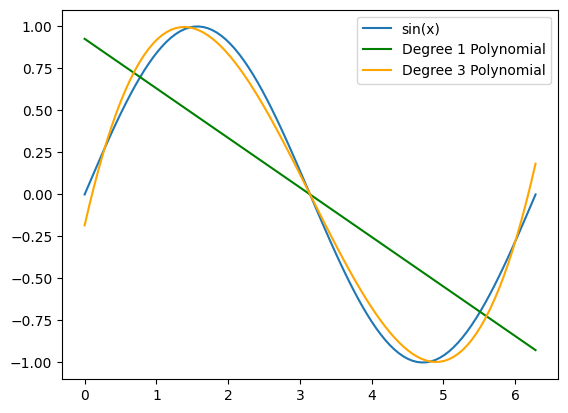

array([2.02558824, 0.45872549])

In [3]:
# ===== Twoja implementacja tutaj =====
coeffs_deg1 = np.polyfit(x, y, 1) 
coeffs_deg3 = np.polyfit(x, y, 3)
poly1 = np.poly1d(coeffs_deg1)
poly3 = np.poly1d(coeffs_deg3)
y_poly1 = poly1(x)
y_poly3 = poly3(x)
plt.plot(x, y, label='sin(x)')
plt.plot(x, y_poly1, label='Degree 1 Polynomial', color='green')
plt.plot(x, y_poly3, label='Degree 3 Polynomial', color='orange')
plt.legend()
plt.show()
main.linear_least_squares(np.array([2,3,4,5,7,9]),np.array([4.87,6.36,8.1,10.92,14.39,18.88]))


---

### **Zadanie 3.**

Należy dokonać aproksymacji funkcjami sklejanymi stopnia trzeciego funkcji na przedziale $[-1, 1]$:

$$
y = \frac{1}{1 + 25x^2}
$$

1. Wygeneruj dwa warianty danych dla funkcji:
    - Pierwszy zestaw z 15. równomiernie rozłożonymi punktami.
    - Drugi zestaw z 15. punktami węzłów Czebyszewa za pomoca funkcji *`chebyshev_nodes()`*.

2. Dokonaj aproksymacji danych przy użyciu splajnów trzeciego stopnia dla obu zestawów punktów.

3. Wyświetl na wykresie zarówno wygenerowane dane, krzywe aproksymacji dla obu zestawów punktów, jak i oryginalny przebieg funkcji. Zwróć uwagę na [efekt Rungego](https://en.wikipedia.org/wiki/Runge's_phenomenon).

4. Czy wykorzystanie węzłów Czebyszewa jest dobrym rozwiązaniem eliminacji efektu Rungego w tym przypadku? Uzasadnij odpowiedź.

> **Wskazówka:** Wykorzystaj funkcje [`sp.interpolate.splrep()`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.splrep.html) i [`sp.interpolate.splev()`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.splev.html) do stworzenia i ewaluacji splajnów.


In [4]:
# ===== Twoja implementacja tutaj =====
y = 1 / (1 + 25 * (x - np.pi) ** 2)



---

### **Zadanie 4.**

Należy wykonać aproksymację poniższej funkcji przy pomocy B-splajnów na przedziale $[-5, 5]$:

$$
y = \sin(x) + 0.1x^2
$$

1. Wygeneruj 20 równomiernie rozłożonych punktów należących do funkcji na przedziale $[-5, 5]$ jako danych.

2. Wykonaj aproksymację używając B-splajnów trzeciego stopnia.

3. Porównaj krzywą aproksymacji z oryginalnymi danymi na wykresie. 

4. Podaj krótką analizę jakości dopasowania B-splajnów do danych.

>**Wskazówka:** Do wygenerowania B-splajnów użyj funkcji [`sp.interpolate.make_splrep()`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.make_splrep.html).


In [5]:
# ===== Twoja implementacja tutaj =====


---

**Materiały uzupełniające:**
- [Scipy Lecture Notes](http://www.scipy-lectures.org/index.html)
- [NumPy for Matlab users](https://docs.scipy.org/doc/numpy/user/numpy-for-matlab-users.html#numpy-for-matlab-users)
- [Python Tutorial - W3Schools](https://www.w3schools.com/python/default.asp)
- [NumPy](https://www.numpy.org)
- [Matplotlib](https://matplotlib.org/)
- [Anaconda](https://www.anaconda.com/)
- [Learn Python for Data Science](https://www.datacamp.com/learn-python-with-anaconda?utm_source=Anaconda_download&utm_campaign=datacamp_training&utm_medium=banner)
- [Learn Python](https://www.learnpython.org/)
- [Wujek Google](https://google.pl) i [Ciocia Wikipedia](https://pl.wikipedia.org/wiki/Wikipedia:Strona_g%C5%82%C3%B3wna)